In [18]:
import pandas as pd

# 讀取檔案
df = pd.read_csv('YRBS_2007.csv')

# 顯示前五筆資料，確認是否讀取成功
df.head()

,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# 設定繪圖風格，讓圖表更美觀
sns.set(style="whitegrid")

C:\Users\a0912\AppData\Local\Temp\ipykernel_1308\2254560358.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_sad', data=df_sad, palette='viridis')


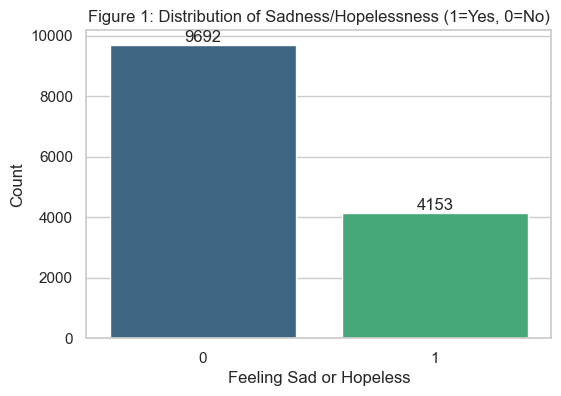

有效樣本數: 13845


In [24]:
# 1. 提取變數並移除缺失值 (Data Check)
df_sad = df[['SadOrHopeless']].dropna().copy()

# 2. 重編碼 (Coding)：1 代表 Yes，其餘代表 No
df_sad['is_sad'] = df_sad['SadOrHopeless'].apply(lambda x: 1 if x == 1 else 0)

# 3. 實質 EDA：繪製次數分配圖
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='is_sad', data=df_sad, palette='viridis')
ax.set_title('Figure 1: Distribution of Sadness/Hopelessness (1=Yes, 0=No)')
ax.set_xlabel('Feeling Sad or Hopeless')
ax.set_ylabel('Count')

# 標註實際人數
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom')
plt.show()

print(f"有效樣本數: {len(df_sad)}")

In [26]:
p0 = 0.30
count = df_sad['is_sad'].sum()
nobs = len(df_sad)

# 執行單一樣本比例 Z 檢定
z_stat, p_val = proportions_ztest(count, nobs, value=p0)

# 計算 95% 信賴區間
ci_low, ci_upp = proportion_confint(count, nobs, alpha=0.05, method='normal')

print(f"--- 比例分析結果 ---")
print(f"樣本比例 (p-hat): {count/nobs:.4f}")
print(f"95% 信賴區間: [{ci_low:.4f}, {ci_upp:.4f}]")
print(f"P 值: {p_val:.4f}")

--- 比例分析結果 ---
樣本比例 (p-hat): 0.3000
95% 信賴區間: [0.2923, 0.3076]
P 值: 0.9926


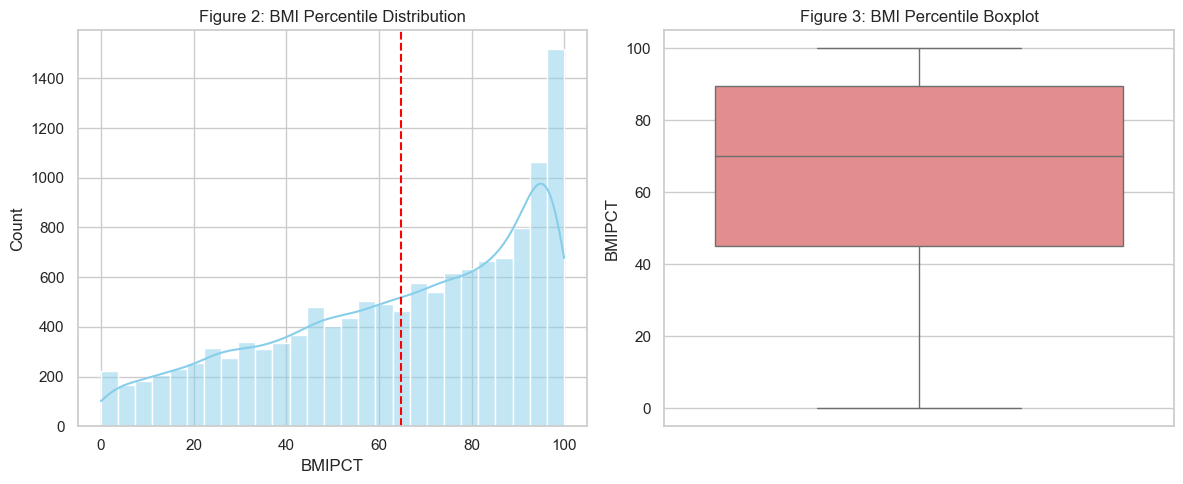

In [28]:
# 1. 提取變數並移除缺失值
df_bmi = df[['BMIPCT']].dropna().copy()

# 2. 實質 EDA：結合直方圖與箱型圖
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 左圖：直方圖看分佈
sns.histplot(df_bmi['BMIPCT'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Figure 2: BMI Percentile Distribution')
ax[0].axvline(df_bmi['BMIPCT'].mean(), color='red', linestyle='--', label='Mean')

# 右圖：箱型圖看離群值
sns.boxplot(y=df_bmi['BMIPCT'], ax=ax[1], color='lightcoral')
ax[1].set_title('Figure 3: BMI Percentile Boxplot')

plt.tight_layout()
plt.show()

In [30]:
mu0 = 65.0
sample_mean = df_bmi['BMIPCT'].mean()

# 執行單一樣本 T 檢定
t_stat, p_val_t = stats.ttest_1samp(df_bmi['BMIPCT'], popmean=mu0)

# 計算平均數的 95% 信賴區間
ci_t = stats.t.interval(0.95, len(df_bmi)-1, loc=sample_mean, scale=stats.sem(df_bmi['BMIPCT']))

print(f"--- 平均數分析結果 ---")
print(f"樣本平均數: {sample_mean:.4f}")
print(f"95% 信賴區間: [{ci_t[0]:.4f}, {ci_t[1]:.4f}]")
print(f"P 值: {p_val_t:.4f}")

--- 平均數分析結果 ---
樣本平均數: 64.8207
95% 信賴區間: [64.3487, 65.2926]
P 值: 0.4564
